In [9]:
import h5py
import os, glob
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_velocity_trace(total_time_s, sample_freq_hz,
                                half_life_s, vel_std_dps, seed):
    
    T = int(total_time_s * sample_freq_hz) + 1
    dt = 1.0 / sample_freq_hz
    tau = half_life_s / np.log(2)
    alpha = np.exp(-dt / tau)  # AR coefficient

    rng = np.random.default_rng(seed)
    noise = rng.normal(0, vel_std_dps, size=T)

    vel = np.zeros(T)
    for t in range(1, T):
        vel[t] = alpha * vel[t-1] + np.sqrt(1 - alpha**2) * noise[t]

    return vel


In [21]:
data_path = 'pano_scenes/'
mat_files = sorted(glob.glob(os.path.join(data_path, "*.mat")))
if not mat_files:
    raise FileNotFoundError("No .mat files found in directory")
# Good scenes in MATLAB indexing (convert to 0-based)
good_ids = (
      [29,31,32]
    + list(range(35,56))
    + [62,63]
    + list(range(72,89))
    + [91,93]
)

goodScenes = [i - 1 for i in good_ids]

all_imgs = []

for fname in mat_files:
    with h5py.File(fname, 'r') as f:
        if "projection" not in f:
            raise KeyError(f"{fname} does not contain 'projection'")
        proj = np.array(f["projection"]).T

    # img = proj / np.max(proj)
    all_imgs.append(proj)

# Convert and FILTER IMMEDIATELY
all_imgs = np.array(all_imgs)
# all_imgs = all_imgs[goodScenes] 
global_min = all_imgs.min()
global_max = all_imgs.max()
all_imgs = (all_imgs - global_min) / (global_max - global_min + 1e-8)
print(f"Loaded {len(all_imgs)} good scenes out of {len(mat_files)} total.")
print(f"Each image shape: {all_imgs[0].shape}")

Loaded 109 good scenes out of 109 total.
Each image shape: (251, 927)


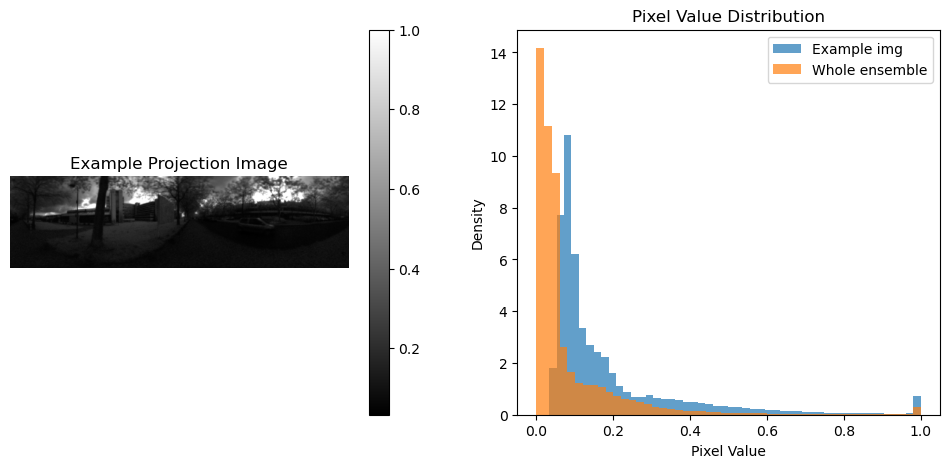

In [40]:
idx = 1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im = axes[0].imshow(all_imgs[idx], cmap='gray')
axes[0].set_title("Example Projection Image")
axes[0].axis('off')

axes[1].hist(all_imgs[idx].flatten(), bins=50, density=True, alpha=0.7, label='Example img')
axes[1].hist(all_imgs.flatten(), bins=50, density=True, alpha=0.7, label='Whole ensemble')
plt.colorbar(im, ax=axes[0])
axes[1].set_title("Pixel Value Distribution")
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Density")
axes[1].legend()